In [47]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt
import spikeinterface.extractors as se
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np

In [78]:
datapath = r"D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20_merged.rec"

#se.read is the class function used to read in spikegadgets it requres file path and stream id = trodes for ephys ECU is used for medpc
recording = se.read_spikegadgets(datapath, stream_id = 'trodes')
print(recording)

SpikeGadgetsRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 2,130,064 samples 
                                106.50s (1.78 minutes) - int16 dtype - 130.01 MiB
  file_path: D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20_merged.rec


In [63]:
# Check the available attributes and methods of the recording object
print(dir(recording))

# Or print the entire object to inspect its contents
print(recording)


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_annotations', '_channel_slice', '_check_segment_index', '_dtype', '_extra_metadata_from_folder', '_extra_metadata_to_folder', '_frame_slice', '_get_file_path', '_kwargs', '_main_annotations', '_main_features', '_main_ids', '_main_properties', '_orig_samp_freq', '_parent_recording', '_preferred_mp_context', '_properties', '_recording_segments', '_remove_channels', '_resample_rate', '_sampling_frequency', '_save', '_select_segments', '_serializability', '_skip_properties', 'add_recording_segment', 'annotate', 'astype', 'binary_compatible_with', 'channel_ids', 'channel_slice', 'check_if_json_serializable', 'check_if_memory_serializable', 'check_if_

In [67]:
# Check for annotations or metadata in the recording
annotations = recording.get_annotation_keys()
print(annotations)

# If 'stream_id' is listed in the annotations, you can access it like this:
for key in annotations:
    print(f"{key}: {recording.get_annotation(key)}")


['is_filtered']
is_filtered: True


In [66]:
# Check the channel IDs, which might provide insight into the stream configuration
print(recording.channel_ids)

['ECU_Ain1' 'ECU_Ain2' 'ECU_Ain3' 'ECU_Ain4' 'ECU_Ain5' 'ECU_Ain6'
 'ECU_Ain7' 'ECU_Ain8' 'ECU_Aout1' 'ECU_Aout2' 'ECU_Aout3' 'ECU_Aout4']


In [54]:
import os

folder = r"D:\spikegadgets"
for file in os.listdir(folder):
    print(file)


20250402_160732_nancylogger_test.rec
20250407_114703sx3_20.rec


In [49]:
recording_ephys = se.read_spikegadgets(datapath, stream_id='ECU')
print("Ephys:", recording_ephys.get_num_channels(), "channels")




Ephys: 12 channels


In [50]:
import neo

reader = neo.rawio.SpikeGadgetsRawIO(filename=datapath)
reader.parse_header()

# List available stream names
print("Signal streams:")
print(reader.header['signal_streams'])

# List channel info per stream
print("\nSignal channels:")
print(reader.header['signal_channels'])


Signal streams:
[('ECU', 'ECU', '')]

Signal channels:
[('ECU_Ain1', 'ECU_Ain1', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Ain2', 'ECU_Ain2', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Ain3', 'ECU_Ain3', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Ain4', 'ECU_Ain4', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Ain5', 'ECU_Ain5', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Ain6', 'ECU_Ain6', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Ain7', 'ECU_Ain7', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Ain8', 'ECU_Ain8', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Aout1', 'ECU_Aout1', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Aout2', 'ECU_Aout2', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Aout3', 'ECU_Aout3', 20000., 'int16', '', 1., 0., 'ECU', '')
 ('ECU_Aout4', 'ECU_Aout4', 20000., 'int16', '', 1., 0., 'ECU', '')]


Available channels: ['ECU_Ain1' 'ECU_Ain2' 'ECU_Ain3' 'ECU_Ain4' 'ECU_Ain5' 'ECU_Ain6'
 'ECU_Ain7' 'ECU_Ain8' 'ECU_Aout1' 'ECU_Aout2' 'ECU_Aout3' 'ECU_Aout4']


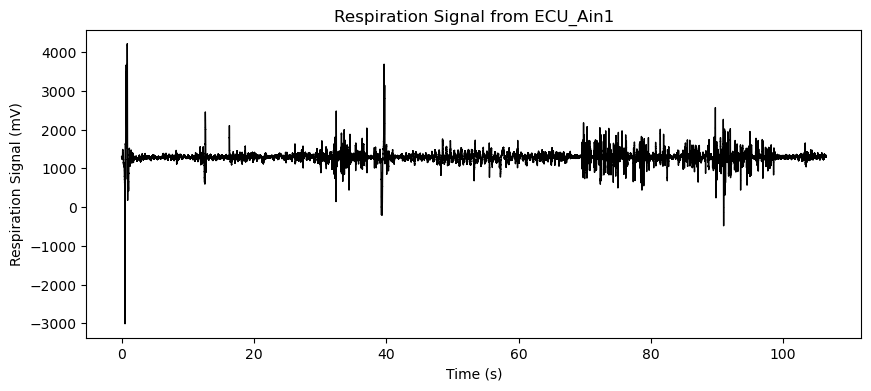

In [46]:

# Define file path
datapath = r"D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20.rec"

# Load recording
recording = se.read_spikegadgets(datapath, stream_id='ECU')

# Print available channel IDs
channel_ids = recording.get_channel_ids()
print("Available channels:", channel_ids)
# Define respiration channel (ECU_Ain1)
resp_channel = 'ECU_Ain1'

# Get sampling rate
fs = recording.get_sampling_frequency()  
# Extract respiration signal
resp_signal = recording.get_traces(channel_ids=[resp_channel]).flatten()

# Create time array
time = np.arange(len(resp_signal)) / fs  # Convert samples to time (seconds)

# Apply Butterworth filter (fix: use sampling_rate instead of fs)
resp_cleaned = nk.signal_filter(
    resp_signal,
    lowcut=0.01,   # Low cutoff frequency (Hz)
    highcut=20,    # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=fs,  # Correct parameter name
    order=2        # Filter order
)



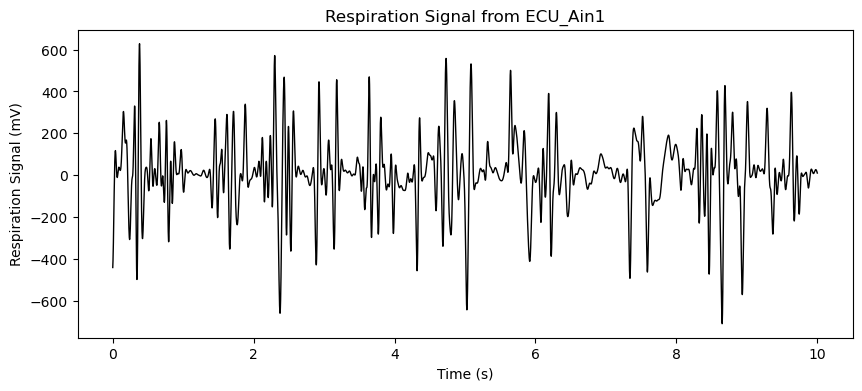

In [87]:
# Define time window (first 10 seconds)
starttime=70
endtime= 80  # seconds
num_samples_start = int(fs * starttime)  # Number of samples for 10 seconds
num_samples_end = int(fs * endtime)
# Slice the first 10 seconds of data
resp_signal_10s = resp_cleaned[num_samples_start:num_samples_end]
time_10s = np.arange(len(resp_signal_10s)) / fs  # Convert to time (s)
# Plot respiration signal
plt.figure(figsize=(10, 4))
plt.plot(time_10s, resp_signal_10s, color='black', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal (mV)")
plt.title(f"Respiration Signal from {resp_channel}")
plt.grid(False)
plt.show()

In [24]:
elec_noise_freq=60
# https://pmc.ncbi.nlm.nih.gov/articles/PMC3130311/ paper suggested these min and max cut offs
min_freq=30
max_freq=1000
resample_rate=1000

In [62]:
datapath = r"D:\spikegadgets\20250402_160732_nancylogger_test.rec\20250402_160732_nancylogger_test.rec"
#se.read is the class function used to read in spikegadgets it requres file path and stream id = trodes for ephys ECU is used for medpc
recording = se.read_spikegadgets(datapath, stream_id = 'ECU')
print(recording)
# removes the noise from the reccording notch filter removes a given freq. 
recording = sp.notch_filter(recording, freq=elec_noise_freq)
# sets filter for a min and max cutoff
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
# resamples transforms data into sampling rates HZ
recording = sp.resample(recording, resample_rate=resample_rate)

SpikeGadgetsRecordingExtractor: 12 channels - 20.0kHz - 1 segments - 2,110,679 samples 
                                105.53s (1.76 minutes) - int16 dtype - 48.31 MiB
  file_path: D:\spikegadgets\20250402_160732_nancylogger_test.rec\20250402_160732_nancylogger_test.rec


In [25]:
datapath = r"D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20.rec"
#se.read is the class function used to read in spikegadgets it requres file path and stream id = trodes for ephys ECU is used for medpc
recording = se.read_spikegadgets(datapath, stream_id = 'ECU')
print(recording)
# removes the noise from the reccording notch filter removes a given freq. 
recording = sp.notch_filter(recording, freq=elec_noise_freq)
# sets filter for a min and max cutoff
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
# resamples transforms data into sampling rates HZ
recording = sp.resample(recording, resample_rate=resample_rate)

SpikeGadgetsRecordingExtractor: 12 channels - 20.0kHz - 1 segments - 2,130,081 samples 
                                106.50s (1.78 minutes) - int16 dtype - 48.75 MiB
  file_path: D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20.rec


In [9]:
# creates a numpy array of the time and channels 
#recoirding = class object that has the meta data and data 
#get_traces is the function that gets me just the data 
traces = recording.get_traces()

In [11]:
channel_ids = recording.get_channel_ids()
print(channel_ids)  # Example: [0, 1, ..., 11]


['ECU_Ain1' 'ECU_Ain2' 'ECU_Ain3' 'ECU_Ain4' 'ECU_Ain5' 'ECU_Ain6'
 'ECU_Ain7' 'ECU_Ain8' 'ECU_Aout1' 'ECU_Aout2' 'ECU_Aout3' 'ECU_Aout4']


In [ ]:
for i in [21,26]:    
    ref_traces=traces[:,i]-traces[:,21]
    plt.plot(ref_traces[1000:12000])
    plt.title(f'channel {i}')
    plt.show()

IndexError: index 21 is out of bounds for axis 1 with size 12